# 02 — Signal exploration

Visual and quantitative patterns in the curated **base dataset** that inform feature design and modeling.

Prerequisites:
- `python scripts/download_usda_data.py`
- `python scripts/download_diesel_data.py`
- notebook `01_data_exploration.ipynb` (modeling audit)

## Setup

- **`raw_dataset`**: full USDA API snapshot (reporting grain, includes commodity/region duplicates).
- **`base_dataset`**: lane-week panel from `build_lane_week_panel()` — the population intended for modeling and scoring (`date + origin + destination`, `rpm = mean`).
- **`diesel_raw`**: weekly on-highway diesel (`x88w-atzp`, EIA via AgTransport) — loaded in §6.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from freight_rates.ingestion import load_raw_snapshot
from freight_rates.preprocessing import build_lane_week_panel

ROOT = Path("..").resolve()
raw_dataset = load_raw_snapshot(raw_dir=ROOT / "data" / "raw")
base_dataset = build_lane_week_panel(raw_dataset)
base_dataset["month"] = pd.to_numeric(base_dataset["month"], errors="coerce").astype("Int64")

print(f"lane-week rows: {len(base_dataset):,}")
print(f"date range: {base_dataset['date'].min().date()} → {base_dataset['date'].max().date()}")
print(f"lanes: {base_dataset['lane_id'].nunique():,} | destinations: {base_dataset['destination'].nunique()}")


lane-week rows: 193,487
date range: 2000-01-04 → 2026-08-18
lanes: 792 | destinations: 10


## 1. Weekly RPM time series

Median RPM each week (global and by destination). Volume overlay shows reporting intensity.


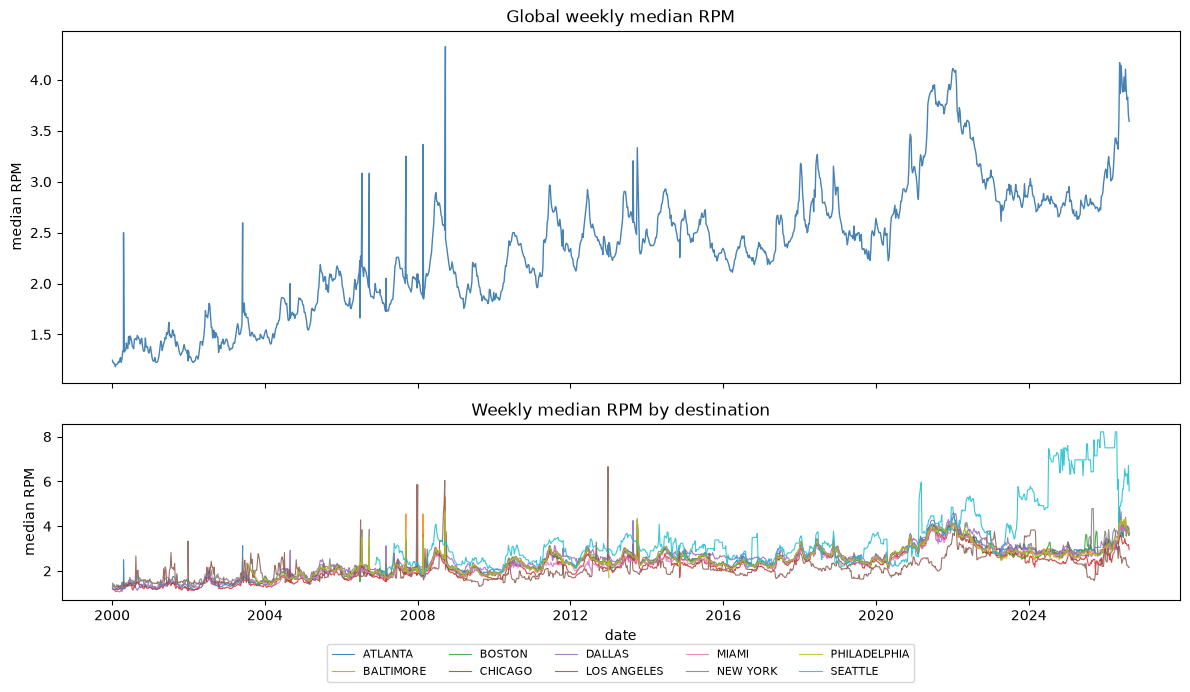

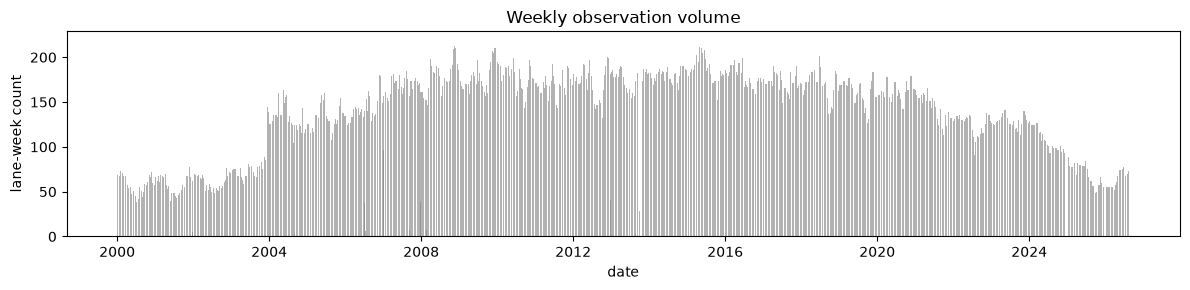

,count,mean,std,min,25%,50%,75%,max
median_rpm,1406.0,2.348021,0.625369,1.184211,1.885585,2.371006,2.75,4.326923


In [2]:
weekly_global = (
    base_dataset.groupby("date", as_index=False)
    .agg(median_rpm=("rpm", "median"), n_obs=("rpm", "count"))
    .sort_values("date")
)

weekly_dest = (
    base_dataset.groupby(["date", "destination"], as_index=False)
    .agg(median_rpm=("rpm", "median"))
    .sort_values(["destination", "date"])
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, height_ratios=[2, 1])
axes[0].plot(weekly_global["date"], weekly_global["median_rpm"], color="steelblue", lw=1)
axes[0].set_ylabel("median RPM")
axes[0].set_title("Global weekly median RPM")

for dest, grp in weekly_dest.groupby("destination"):
    axes[1].plot(grp["date"], grp["median_rpm"], lw=0.8, alpha=0.85, label=dest)
axes[1].set_ylabel("median RPM")
axes[1].set_xlabel("date")
axes[1].set_title("Weekly median RPM by destination")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(weekly_global["date"], weekly_global["n_obs"], width=5, color="gray", alpha=0.6)
ax.set_ylabel("lane-week count")
ax.set_xlabel("date")
ax.set_title("Weekly observation volume")
plt.tight_layout()
plt.show()

weekly_global[["median_rpm"]].describe().T


**Takeaway:** RPM moves with clear multi-year cycles and destination-specific levels. Observation volume is uneven over time — recent years have fewer active weeks/lanes.

That decline is mostly **reporting coverage**, not a collapse in produce trucking. FVWTRK only quotes open (spot) rates when a district is actively shipping and brokers/shippers report; AMS also dropped California→LA short-haul (0–500 mi) rates from 2025 Q1. Treat 2025–26 as partial years when comparing annual totals.


## 2. Origin × destination heatmaps

Top 20 origins by volume. Color = median RPM or observation count.


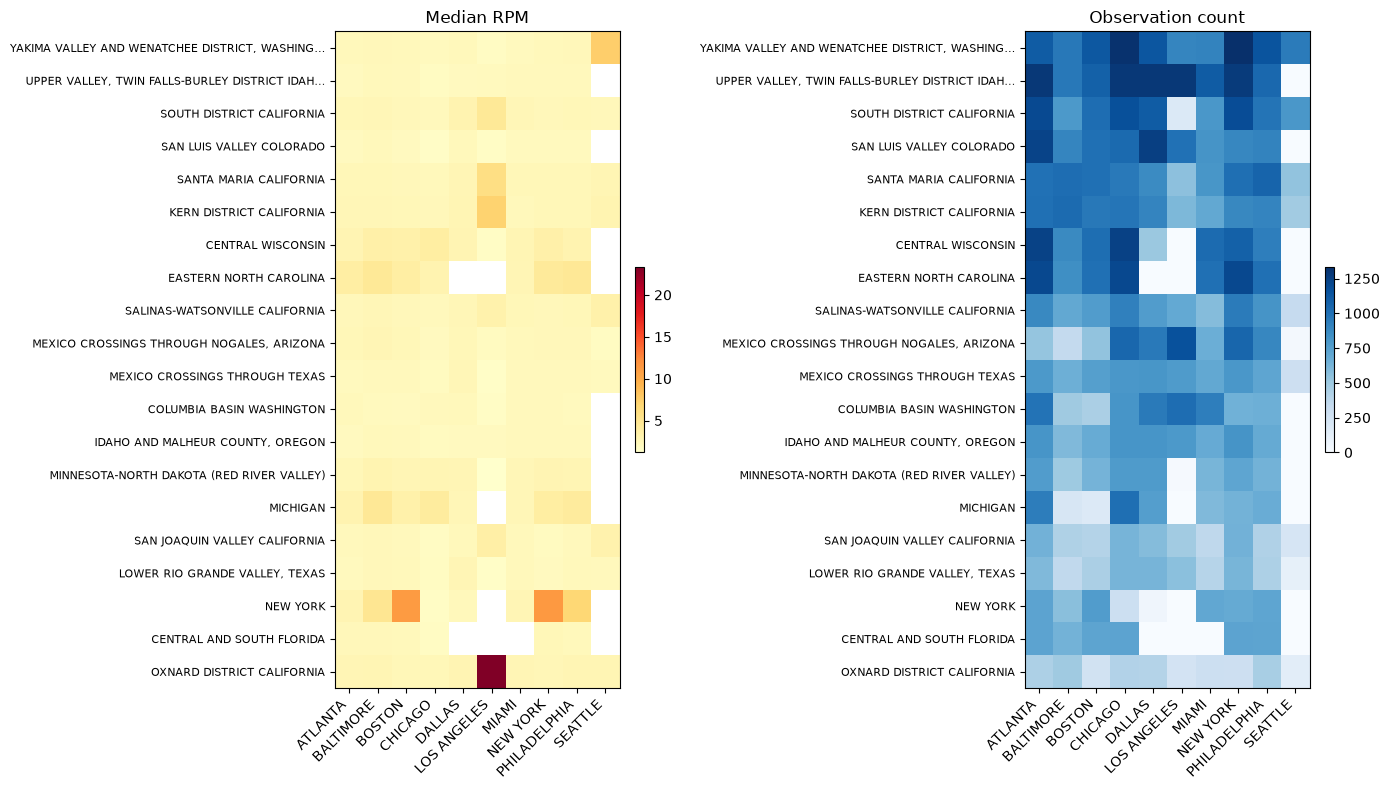

In [3]:
TOP_N = 20
metric_cols = ["rpm", "lane_id"]

top_origins = base_dataset["origin"].value_counts().head(TOP_N).index
destinations = sorted(base_dataset["destination"].unique())
subset = base_dataset[base_dataset["origin"].isin(top_origins)]

rpm_pivot = (
    subset.groupby(["origin", "destination"])["rpm"]
    .median()
    .unstack("destination")
    .reindex(index=top_origins, columns=destinations)
)
count_pivot = (
    subset.groupby(["origin", "destination"])["lane_id"]
    .count()
    .unstack("destination")
    .reindex(index=top_origins, columns=destinations)
    .fillna(0)
)

short_labels = [o[:45] + ("…" if len(o) > 45 else "") for o in top_origins]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, data, title, cmap in [
    (axes[0], rpm_pivot, "Median RPM", "YlOrRd"),
    (axes[1], count_pivot, "Observation count", "Blues"),
]:
    im = ax.imshow(data.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(destinations)))
    ax.set_xticklabels(destinations, rotation=45, ha="right")
    ax.set_yticks(range(len(top_origins)))
    ax.set_yticklabels(short_labels, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()


**Takeaway:** Rate levels and data density vary sharply across OD pairs. Sparse cells (light count heatmap) align with cold-start lanes.


## 3. Seasonality and autocorrelation

Monthly RPM distribution and ACF of the global weekly median series (52-week max lag).


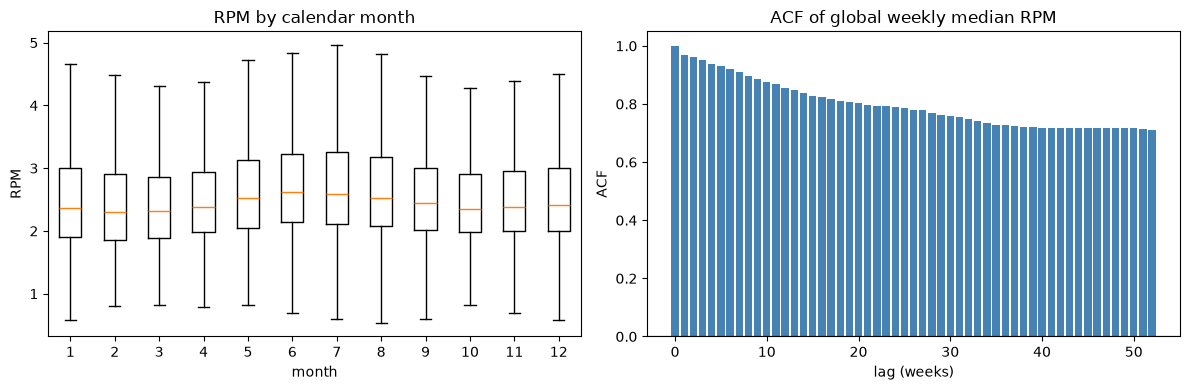

,count,median,mean
month,,,
1,16555,2.365079,2.734514
2,15068,2.307692,2.642871
3,17032,2.321429,2.630930
4,16642,2.379310,2.701003
5,17009,2.517857,2.816786
6,16475,2.626263,2.944053
7,15786,2.591751,2.964194
8,15470,2.519231,2.902702
9,14486,2.446429,2.816738


In [4]:
# Same idea as statsmodels.tsa.stattools.acf
def acf(x: pd.Series, nlags: int = 52) -> pd.Series:
    s = x.dropna().astype(float)
    if len(s) < 2:
        return pd.Series(dtype=float)
    s = s - s.mean()
    denom = (s**2).sum()
    values = {0: 1.0}
    for lag in range(1, min(nlags, len(s) - 1) + 1):
        values[lag] = (s.iloc[:-lag].to_numpy() * s.iloc[lag:].to_numpy()).sum() / denom
    return pd.Series(values)


monthly = base_dataset.copy()
monthly["month"] = monthly["month"].astype(int)
monthly_box = [monthly.loc[monthly["month"] == m, "rpm"].dropna().values for m in range(1, 13)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(monthly_box, tick_labels=list(range(1, 13)), showfliers=False)
axes[0].set_xlabel("month")
axes[0].set_ylabel("RPM")
axes[0].set_title("RPM by calendar month")

acf_vals = acf(weekly_global.set_index("date")["median_rpm"], nlags=52)
axes[1].bar(acf_vals.index, acf_vals.values, color="steelblue", width=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("lag (weeks)")
axes[1].set_ylabel("ACF")
axes[1].set_title("ACF of global weekly median RPM")
plt.tight_layout()
plt.show()

base_dataset.groupby("month")["rpm"].agg(["count", "median", "mean"]).astype({"median": float, "mean": float})


**Takeaway:** Summer months tend to show higher RPM dispersion...more competition for reefers?; weekly RPM is autocorrelated, supporting lag features (`rpm_lag_1`, rolling means).


### 3.1 Does seasonality add signal beyond lag-1?

The raw monthly RPM chart can be confounded by lane composition, long-run inflation, and changing coverage. This diagnostic therefore asks two stricter questions:

1. **Within lane-year:** after subtracting each lane's annual mean, is there a recurring calendar profile?
2. **Operationally under Case B:** in an expanding-window test restricted to the model window (`date >= 2024-07-01`), can a train-only Fourier correction improve the prior-observation (`rpm_lag_1`) baseline?

The second test predicts the change `rpm_t - rpm_lag_1` using annual Fourier terms. It reports a global seasonal correction and a region-specific correction. These are deliberately simple diagnostic models, not candidates selected or tuned on the official evaluation results. Rows without a prior lane observation are excluded because this section tests incremental signal **beyond lag-1**, not cold-start performance.

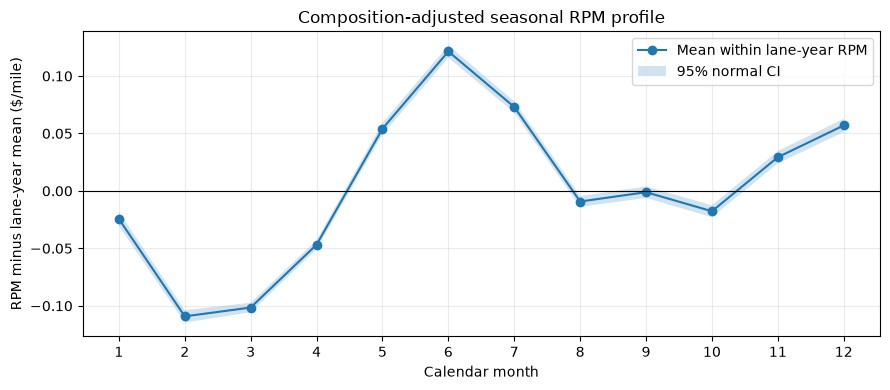

,month,n,mean_within_rpm,median_within_rpm,ci95_low,ci95_high
0,1,15086,-0.024366,-0.038109,-0.030431,-0.018301
1,2,13362,-0.109184,-0.094116,-0.114641,-0.103727
2,3,14874,-0.101514,-0.079308,-0.105685,-0.097344
3,4,14131,-0.046802,-0.035474,-0.050770,-0.042834
4,5,13960,0.054109,0.002442,0.049069,0.059149
5,6,12352,0.121362,0.070235,0.115924,0.126800
6,7,11200,0.073041,0.041700,0.068107,0.077975
7,8,10873,-0.009228,-0.011124,-0.013940,-0.004515
8,9,11633,-0.001122,0.000000,-0.006144,0.003900
9,10,13050,-0.017702,-0.006321,-0.022918,-0.012486


In [5]:
# Composition-adjusted seasonal profile: subtract each lane-year's mean RPM.
seasonal = base_dataset.copy()
seasonal["calendar_year"] = seasonal["date"].dt.year
seasonal["week_of_year"] = seasonal["date"].dt.isocalendar().week.astype(int)
seasonal["month"] = seasonal["date"].dt.month

lane_year = seasonal.groupby(["lane_id", "calendar_year"])["rpm"]
seasonal["lane_year_n"] = lane_year.transform("size")
seasonal["rpm_within_lane_year"] = seasonal["rpm"] - lane_year.transform("mean")

# Require enough observations to estimate a lane-year level sensibly.
seasonal_complete = seasonal.loc[seasonal["lane_year_n"] >= 20].copy()
monthly_within = (
    seasonal_complete.groupby("month", as_index=False)
    .agg(
        n=("rpm_within_lane_year", "size"),
        mean_within_rpm=("rpm_within_lane_year", "mean"),
        median_within_rpm=("rpm_within_lane_year", "median"),
        std_within_rpm=("rpm_within_lane_year", "std"),
    )
)
monthly_within["se"] = monthly_within["std_within_rpm"] / np.sqrt(monthly_within["n"])
monthly_within["ci95_low"] = monthly_within["mean_within_rpm"] - 1.96 * monthly_within["se"]
monthly_within["ci95_high"] = monthly_within["mean_within_rpm"] + 1.96 * monthly_within["se"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly_within["month"], monthly_within["mean_within_rpm"], marker="o", label="Mean within lane-year RPM")
ax.fill_between(
    monthly_within["month"],
    monthly_within["ci95_low"],
    monthly_within["ci95_high"],
    alpha=0.2,
    label="95% normal CI",
)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Calendar month")
ax.set_ylabel("RPM minus lane-year mean ($/mile)")
ax.set_title("Composition-adjusted seasonal RPM profile")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

monthly_within[["month", "n", "mean_within_rpm", "median_within_rpm", "ci95_low", "ci95_high"]]

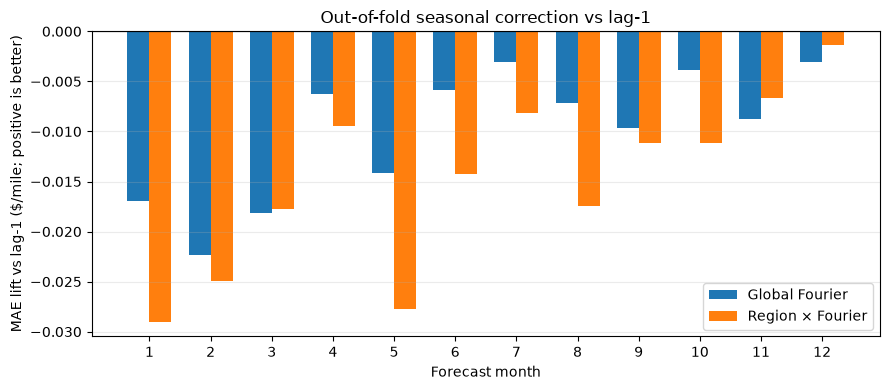

,segment,n,lag1_mae,fourier_mae,region_fourier_mae,fourier_lift_vs_lag1,region_fourier_lift_vs_lag1
0,all prior observations,5640,0.131913,0.142539,0.148364,-0.010626,-0.016451
1,exactly one week ago,5477,0.118736,0.129795,0.136713,-0.011059,-0.017976
2,stale prior observation (>1 week),163,0.574676,0.570734,0.539867,0.003942,0.034809


,month,n,lag1_mae,fourier_mae,region_fourier_mae,fourier_lift,region_fourier_lift
0,1,550,0.157655,0.174640,0.186684,-0.016985,-0.029029
1,2,531,0.116106,0.138450,0.141026,-0.022345,-0.024920
2,3,580,0.075860,0.093982,0.093596,-0.018122,-0.017736
3,4,640,0.088683,0.094950,0.098166,-0.006267,-0.009483
4,5,610,0.207226,0.221374,0.234967,-0.014148,-0.027742
5,6,692,0.153892,0.159748,0.168100,-0.005856,-0.014208
6,7,630,0.164032,0.167090,0.172143,-0.003059,-0.008111
7,8,464,0.125897,0.133086,0.143328,-0.007189,-0.017431
8,9,276,0.088287,0.097956,0.099473,-0.009669,-0.011186
9,10,203,0.093595,0.097456,0.104742,-0.003861,-0.011148


In [6]:
from sklearn.linear_model import Ridge

from freight_rates.splits import FIRST_FORECAST_DATE, filter_model_window


def fourier_matrix(frame: pd.DataFrame, harmonics: int = 2) -> np.ndarray:
    """Annual Fourier terms known ex ante for each forecast date."""
    week = frame["date"].dt.isocalendar().week.astype(float).to_numpy()
    columns = []
    for k in range(1, harmonics + 1):
        angle = 2 * np.pi * k * week / 52.1775
        columns.extend([np.sin(angle), np.cos(angle)])
    return np.column_stack(columns)


def region_fourier_matrices(
    train: pd.DataFrame,
    score: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray]:
    """Global Fourier terms plus train-known region levels and interactions."""
    x_train_fourier = fourier_matrix(train)
    x_score_fourier = fourier_matrix(score)

    train_region = pd.get_dummies(train["region"].fillna("UNKNOWN"), prefix="region", dtype=float)
    score_region = pd.get_dummies(score["region"].fillna("UNKNOWN"), prefix="region", dtype=float)
    score_region = score_region.reindex(columns=train_region.columns, fill_value=0.0)

    train_r = train_region.to_numpy()
    score_r = score_region.to_numpy()
    train_interactions = np.einsum("ij,ik->ijk", train_r, x_train_fourier).reshape(len(train), -1)
    score_interactions = np.einsum("ij,ik->ijk", score_r, x_score_fourier).reshape(len(score), -1)

    return (
        np.column_stack([x_train_fourier, train_r, train_interactions]),
        np.column_stack([x_score_fourier, score_r, score_interactions]),
    )


# Rebuild lags only after filtering: history before the API/model-window start is intentionally unavailable.
recent = filter_model_window(base_dataset).sort_values(["origin", "destination", "date"]).copy()
lane = recent.groupby(["origin", "destination"], sort=False)
recent["prev_date"] = lane["date"].shift(1)
recent["rpm_lag_1"] = lane["rpm"].shift(1)
recent["gap_weeks"] = (recent["date"] - recent["prev_date"]).dt.days / 7.0
recent["rpm_change"] = recent["rpm"] - recent["rpm_lag_1"]
paired = recent.dropna(subset=["rpm_lag_1", "rpm_change"]).copy()

records = []
forecast_dates = sorted(paired.loc[paired["date"] >= FIRST_FORECAST_DATE, "date"].unique())
for t in forecast_dates:
    train = paired.loc[paired["date"] < t]
    score = paired.loc[paired["date"] == t]
    if train.empty or score.empty:
        continue

    # Diagnostic 1: one global annual Fourier correction to lag-1.
    global_model = Ridge(alpha=10.0)
    global_model.fit(fourier_matrix(train), train["rpm_change"])
    global_delta = global_model.predict(fourier_matrix(score))

    # Diagnostic 2: allow the annual profile to differ by USDA region.
    x_train_region, x_score_region = region_fourier_matrices(train, score)
    region_model = Ridge(alpha=10.0)
    region_model.fit(x_train_region, train["rpm_change"])
    region_delta = region_model.predict(x_score_region)

    fold = pd.DataFrame(
        {
            "date": score["date"].to_numpy(),
            "month": score["date"].dt.month.to_numpy(),
            "gap_weeks": score["gap_weeks"].to_numpy(),
            "y_true": score["rpm"].to_numpy(),
            "pred_lag1": score["rpm_lag_1"].to_numpy(),
            "pred_fourier": score["rpm_lag_1"].to_numpy() + global_delta,
            "pred_region_fourier": score["rpm_lag_1"].to_numpy() + region_delta,
        }
    )
    records.append(fold)

seasonal_oof = pd.concat(records, ignore_index=True)
for prediction in ("pred_lag1", "pred_fourier", "pred_region_fourier"):
    seasonal_oof[f"ae_{prediction}"] = (seasonal_oof["y_true"] - seasonal_oof[prediction]).abs()


def seasonal_metric_row(frame: pd.DataFrame, segment: str) -> dict:
    return {
        "segment": segment,
        "n": len(frame),
        "lag1_mae": frame["ae_pred_lag1"].mean(),
        "fourier_mae": frame["ae_pred_fourier"].mean(),
        "region_fourier_mae": frame["ae_pred_region_fourier"].mean(),
        "fourier_lift_vs_lag1": frame["ae_pred_lag1"].mean() - frame["ae_pred_fourier"].mean(),
        "region_fourier_lift_vs_lag1": frame["ae_pred_lag1"].mean() - frame["ae_pred_region_fourier"].mean(),
    }

seasonal_summary = pd.DataFrame(
    [
        seasonal_metric_row(seasonal_oof, "all prior observations"),
        seasonal_metric_row(seasonal_oof.loc[seasonal_oof["gap_weeks"] == 1], "exactly one week ago"),
        seasonal_metric_row(seasonal_oof.loc[seasonal_oof["gap_weeks"] > 1], "stale prior observation (>1 week)"),
    ]
)

monthly_lift = (
    seasonal_oof.groupby("month")
    .agg(
        n=("y_true", "size"),
        lag1_mae=("ae_pred_lag1", "mean"),
        fourier_mae=("ae_pred_fourier", "mean"),
        region_fourier_mae=("ae_pred_region_fourier", "mean"),
    )
    .reset_index()
)
monthly_lift["fourier_lift"] = monthly_lift["lag1_mae"] - monthly_lift["fourier_mae"]
monthly_lift["region_fourier_lift"] = monthly_lift["lag1_mae"] - monthly_lift["region_fourier_mae"]

fig, ax = plt.subplots(figsize=(9, 4))
width = 0.36
ax.bar(monthly_lift["month"] - width / 2, monthly_lift["fourier_lift"], width=width, label="Global Fourier")
ax.bar(monthly_lift["month"] + width / 2, monthly_lift["region_fourier_lift"], width=width, label="Region × Fourier")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Forecast month")
ax.set_ylabel("MAE lift vs lag-1 ($/mile; positive is better)")
ax.set_title("Out-of-fold seasonal correction vs lag-1")
ax.legend()
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(seasonal_summary)
display(monthly_lift)

**Result:** There is a clear *descriptive* annual pattern after controlling for lane-year level: February–March average roughly **$0.10/mile below** the lane-year mean, while June averages roughly **$0.12/mile above** it. The narrow intervals indicate that this historical profile is not explained only by changing lane composition.

However, that pattern does **not** translate into incremental predictive value under the current Case B/model-window setup. Across 5,640 out-of-fold rows, lag-1 MAE is **0.132**, versus **0.143** for the global Fourier correction and **0.148** for region × Fourier. Both corrections are worse in every calendar month. The likely reason is that the model starts with only July–December 2024 as burn-in, so an annual profile is weakly identified and may not be stable enough to improve a highly persistent weekly series.

One narrow exception is stale history (`gap_weeks > 1`, only 163 rows): region × Fourier reduces MAE from **0.575 to 0.540**. That is promising but too small a subgroup to justify adding calendar Fourier terms globally.

**Decision for modeling:** do not add Fourier seasonality to the main GBM yet. First add `weeks_since_last_observation` and evaluate a gated correction only for stale lags; retain ex-ante calendar variables as controls, but do not expect them to beat lag-1 on ordinary consecutive weeks. A future experiment could revisit seasonality with a longer allowed training window or a 52-week lag once enough in-window history exists.

## 4. Availability vs RPM

Relationship between truck availability and rate per mile.


Pearson(availability, rpm):  0.0755
Spearman(availability, rpm): 0.1389


,count,median,mean
availability,,,
1,11286,2.067805,2.173844
2,13543,2.153846,2.303484
3,117683,2.478704,2.879326
4,29345,2.476190,2.808637
5,21630,2.566391,2.815356


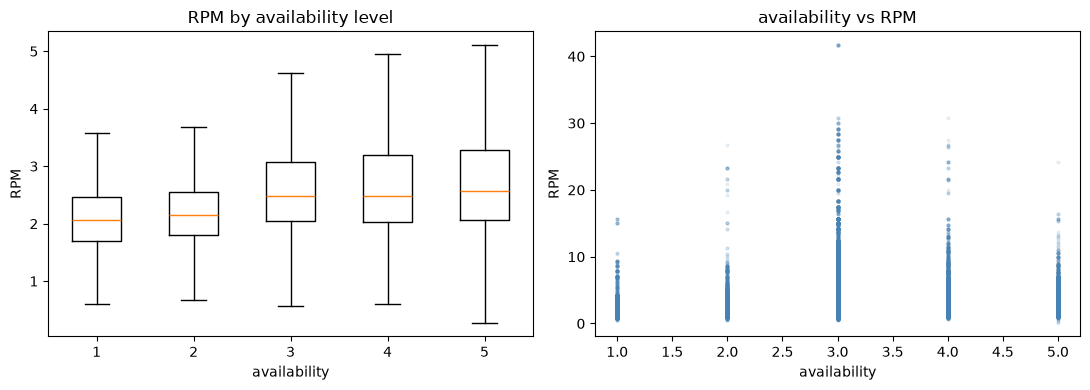

In [7]:
avail = base_dataset.dropna(subset=["availability", "rpm"]).copy()
avail["availability"] = avail["availability"].round().astype(int)

pearson = avail["availability"].corr(avail["rpm"], method="pearson")
spearman = avail["availability"].corr(avail["rpm"], method="spearman")
print(f"Pearson(availability, rpm):  {pearson:.4f}")
print(f"Spearman(availability, rpm): {spearman:.4f}")

by_avail = (
    avail.groupby("availability")["rpm"]
    .agg(count="count", median="median", mean="mean")
    .sort_index()
)
display(by_avail)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].boxplot(
    [avail.loc[avail["availability"] == a, "rpm"] for a in sorted(avail["availability"].unique())],
    tick_labels=sorted(avail["availability"].unique()),
    showfliers=False,
)
axes[0].set_xlabel("availability")
axes[0].set_ylabel("RPM")
axes[0].set_title("RPM by availability level")

axes[1].scatter(avail["availability"], avail["rpm"], s=4, alpha=0.1, color="steelblue")
axes[1].set_xlabel("availability")
axes[1].set_ylabel("RPM")
axes[1].set_title("availability vs RPM")
plt.tight_layout()
plt.show()


**Takeaway:* Makes sense that Availability = 5 (shortage) is associeted with higher RPM. 


## 5. Example lane series

Ten highest-volume lanes — weekly RPM over the full history.


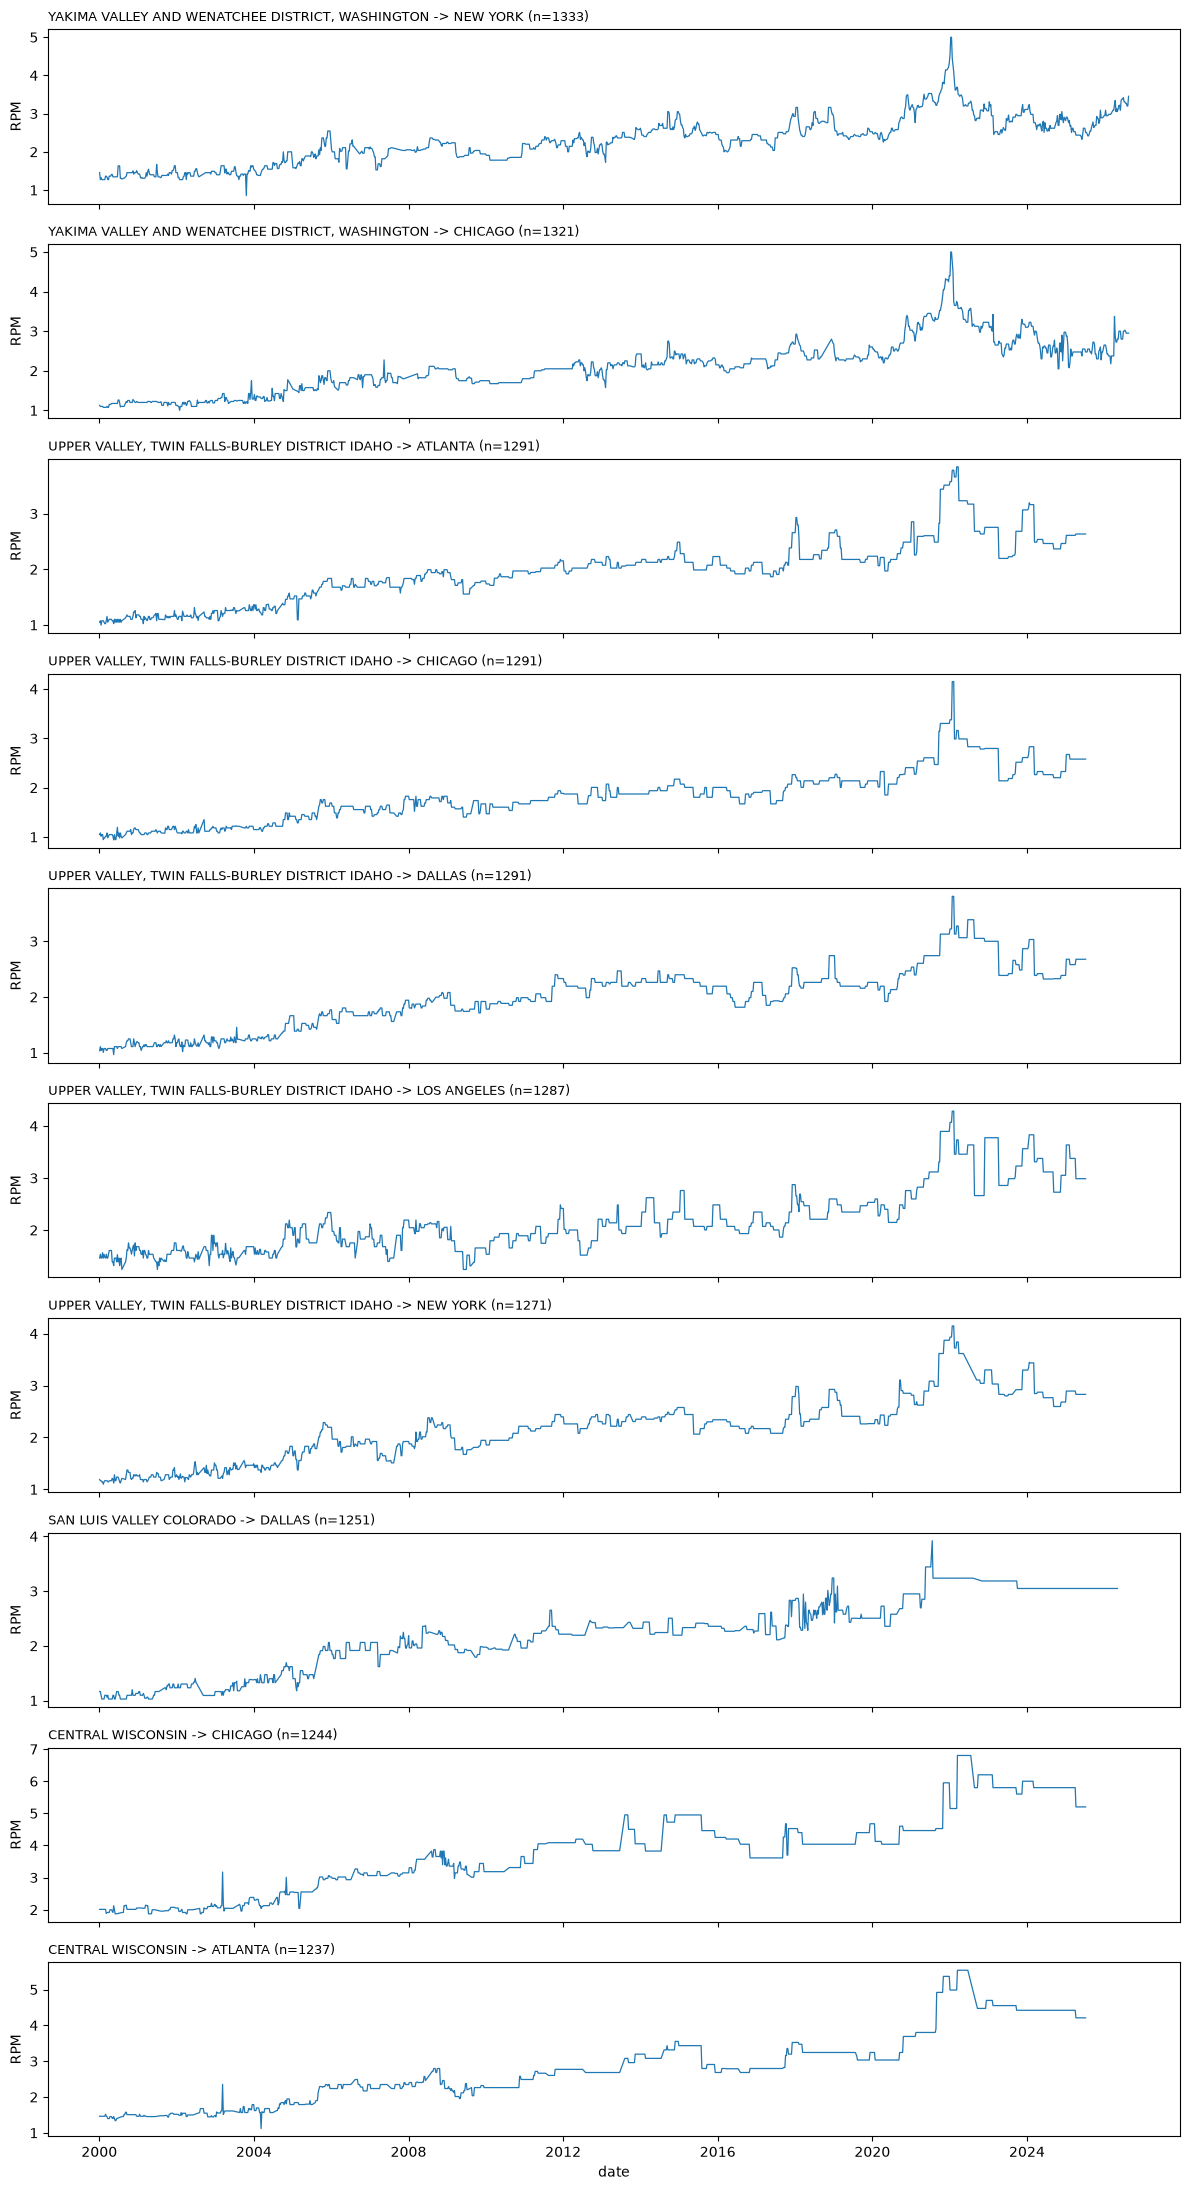

,count,median,std
lane_id,,,
"YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON -> NEW YORK",1333,2.309091,0.597012
"YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON -> CHICAGO",1321,2.100000,0.648753
"UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> ATLANTA",1291,2.021463,0.539659
"UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> CHICAGO",1291,1.804403,0.512345
"UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> DALLAS",1291,2.056774,0.538595
"UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> LOS ANGELES",1287,2.070130,0.617823
"UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> NEW YORK",1271,2.215532,0.588721
SAN LUIS VALLEY COLORADO -> DALLAS,1251,2.272603,0.644791
CENTRAL WISCONSIN -> CHICAGO,1244,3.836000,1.206787


In [8]:
EXAMPLE_LANES = 10
example_ids = base_dataset["lane_id"].value_counts().head(EXAMPLE_LANES).index
example = base_dataset[base_dataset["lane_id"].isin(example_ids)].copy()

fig, axes = plt.subplots(EXAMPLE_LANES, 1, figsize=(12, 2.2 * EXAMPLE_LANES), sharex=True)
if EXAMPLE_LANES == 1:
    axes = [axes]

for ax, lane_id, grp in zip(axes, example_ids, [example[example["lane_id"] == lid] for lid in example_ids]):
    grp = grp.sort_values("date")
    ax.plot(grp["date"], grp["rpm"], lw=0.9)
    ax.set_ylabel("RPM")
    ax.set_title(f"{lane_id} (n={len(grp)})", fontsize=9, loc="left")
axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()

example.groupby("lane_id")["rpm"].agg(["count", "median", "std"]).sort_values("count", ascending=False)


**Takeaway:** Mature lanes show persistent level differences and visible seasonality; individual lane noise confirms the need for pooling or hierarchical models on sparse lanes.


## 6. Diesel — grain, levels, and link to RPM

**Unit of time: weekly, not daily.** EIA / AgTransport `x88w-atzp` publishes **one retail on-highway diesel price per region per week**, dated to the **week-ending Monday** ($/gallon). Rate `date` is week-ending **Tuesday**, so joins must be as-of (Case B: diesel Monday `<= t − 7`).

Source: `scripts/download_diesel_data.py` → `data/raw/usda_diesel_weekly.parquet`.

Diesel grain (US series)
  rows:           117
  date range:     2024-06-03 → 2026-08-24
  weekday (mode): Monday  (all Monday=True)
  gap days:       median=7, min=7, max=7
  Case-B asof lag: 7 days (rate Tuesday t → diesel Monday <= t-7)

Raw snapshot regions: ['US']


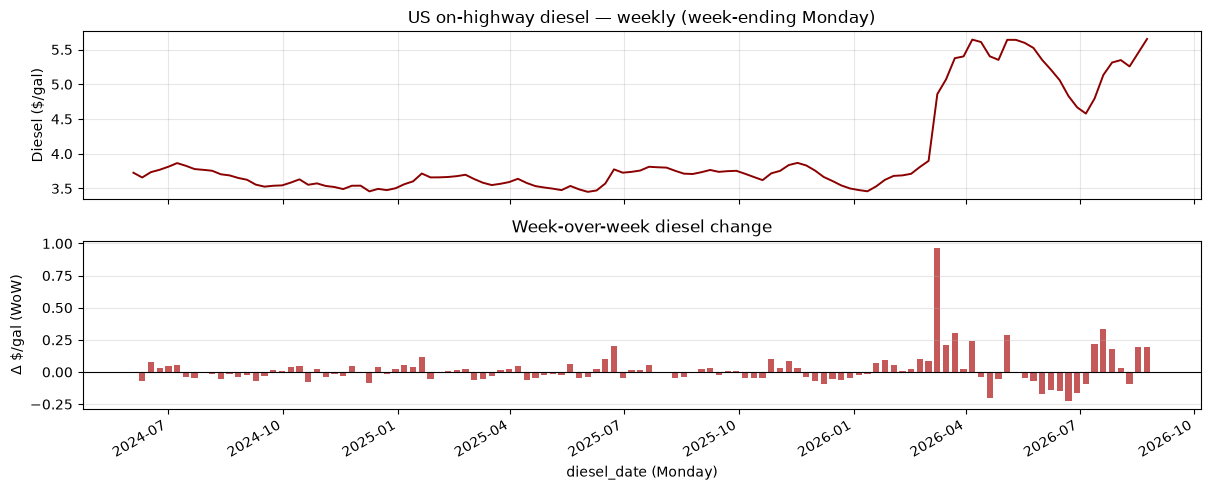

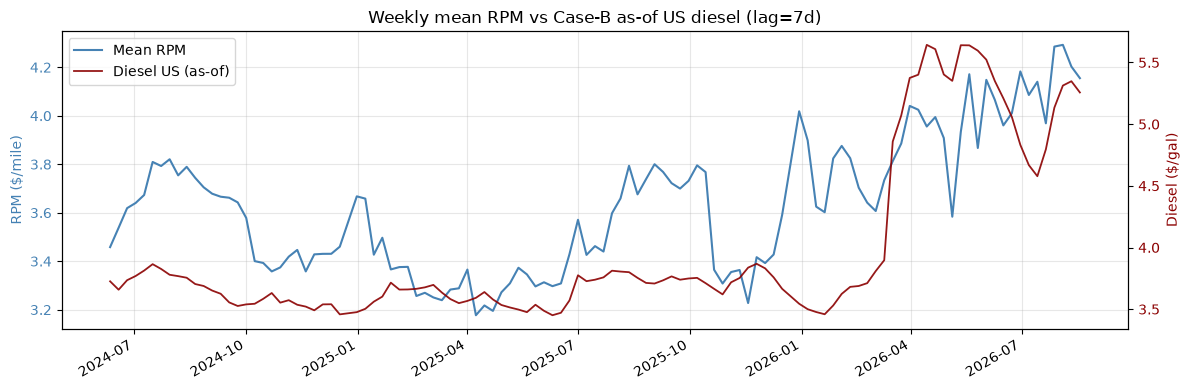

Association (lane-weeks with diesel attached):
  corr(weekly mean RPM, diesel_us)           = +0.723
  corr(rpm, diesel_us)                       = +0.080
  corr(rpm, diesel_us_chg_1w)                = +0.008
  corr(rpm−rpm_lag1, diesel_us_chg_1w)       = +0.049
  asof gap (rate_date − diesel_date) days: min=8, median=8


,week_ending_monday,diesel_us,diesel_us_chg_1w
109,2026-07-06,4.578,-0.090
110,2026-07-13,4.796,0.218
111,2026-07-20,5.134,0.338
112,2026-07-27,5.313,0.179
113,2026-08-03,5.348,0.035
114,2026-08-10,5.257,-0.091
115,2026-08-17,5.454,0.197
116,2026-08-24,5.652,0.198


In [9]:
from freight_rates.diesel import (
    DIESEL_ASOF_LAG_DAYS,
    attach_diesel_asof,
    load_diesel_snapshot,
    prepare_us_diesel_series,
)

diesel_raw = load_diesel_snapshot(raw_dir=ROOT / "data" / "raw")
diesel_us = prepare_us_diesel_series(diesel_raw, region="US")

# --- Grain diagnostics: weekly Mondays, ~7-day spacing ---
gaps = diesel_us["diesel_date"].diff().dt.days.dropna()
print("Diesel grain (US series)")
print(f"  rows:           {len(diesel_us):,}")
print(f"  date range:     {diesel_us['diesel_date'].min().date()} → {diesel_us['diesel_date'].max().date()}")
print(f"  weekday (mode): {diesel_us['diesel_date'].dt.day_name().mode().iloc[0]}  "
      f"(all Monday={bool((diesel_us['diesel_date'].dt.dayofweek == 0).all())})")
print(f"  gap days:       median={gaps.median():.0f}, min={gaps.min():.0f}, max={gaps.max():.0f}")
print(f"  Case-B asof lag: {DIESEL_ASOF_LAG_DAYS} days (rate Tuesday t → diesel Monday <= t-7)")
print()
print("Raw snapshot regions:", sorted(diesel_raw["region"].astype(str).unique()))

# --- Levels + WoW change ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(diesel_us["diesel_date"], diesel_us["diesel_us"], color="darkred", lw=1.4)
axes[0].set_ylabel("Diesel ($/gal)")
axes[0].set_title("US on-highway diesel — weekly (week-ending Monday)")
axes[0].grid(True, alpha=0.3)

axes[1].bar(
    diesel_us["diesel_date"],
    diesel_us["diesel_us_chg_1w"],
    width=5,
    color="firebrick",
    alpha=0.75,
)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Δ $/gal (WoW)")
axes[1].set_xlabel("diesel_date (Monday)")
axes[1].set_title("Week-over-week diesel change")
axes[1].grid(True, axis="y", alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# --- Overlay with weekly mean RPM after Case-B as-of merge ---
panel_diesel = attach_diesel_asof(base_dataset, diesel_raw)
weekly = (
    panel_diesel.groupby("date", as_index=False)
    .agg(rpm=("rpm", "mean"), diesel_us=("diesel_us", "first"), n=("rpm", "size"))
    .dropna(subset=["diesel_us"])
    .sort_values("date")
)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(weekly["date"], weekly["rpm"], color="steelblue", lw=1.5, label="Mean RPM")
ax1.set_ylabel("RPM ($/mile)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(weekly["date"], weekly["diesel_us"], color="darkred", lw=1.3, alpha=0.9, label="Diesel US (as-of)")
ax2.set_ylabel("Diesel ($/gal)", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

ax1.set_title(f"Weekly mean RPM vs Case-B as-of US diesel (lag={DIESEL_ASOF_LAG_DAYS}d)")
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate()
# Combined legend
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [ln.get_label() for ln in lines], loc="upper left")
plt.tight_layout()
plt.show()

# --- Simple association (levels + changes); not causal ---
corr = weekly[["rpm", "diesel_us"]].corr().iloc[0, 1]
# Align WoW diesel change already on panel; correlate with rpm and rpm vs lag-1 residual proxy
panel_diesel = panel_diesel.sort_values(["lane_id", "date"])
panel_diesel["rpm_lag1"] = panel_diesel.groupby("lane_id")["rpm"].shift(1)
panel_diesel["rpm_resid_lag1"] = panel_diesel["rpm"] - panel_diesel["rpm_lag1"]

assoc = panel_diesel.dropna(subset=["diesel_us", "diesel_us_chg_1w", "rpm"]).copy()
print("Association (lane-weeks with diesel attached):")
print(f"  corr(weekly mean RPM, diesel_us)           = {corr:+.3f}")
print(f"  corr(rpm, diesel_us)                       = {assoc['rpm'].corr(assoc['diesel_us']):+.3f}")
print(f"  corr(rpm, diesel_us_chg_1w)                = {assoc['rpm'].corr(assoc['diesel_us_chg_1w']):+.3f}")
sub = assoc.dropna(subset=["rpm_resid_lag1"])
print(
    f"  corr(rpm−rpm_lag1, diesel_us_chg_1w)       = "
    f"{sub['rpm_resid_lag1'].corr(sub['diesel_us_chg_1w']):+.3f}"
)
print(f"  asof gap (rate_date − diesel_date) days: "
      f"min={(assoc['date'] - assoc['diesel_date']).dt.days.min()}, "
      f"median={(assoc['date'] - assoc['diesel_date']).dt.days.median():.0f}")

display(
    diesel_us.tail(8).rename(columns={"diesel_date": "week_ending_monday"})
)

**Takeaway:** Diesel is a **weekly Monday** series ($/gal), not daily. Aggregate weekly mean RPM co-moves with diesel levels over the sample, but at the lane-week grain the correlation is weak, and WoW diesel changes add little beyond lag-1. Keep diesel as an exogenous cost feature (`diesel_us`, `diesel_us_chg_1w`) with the Case-B as-of rule — never same-week Monday for Tuesday `t`.

## Summary — modeling implications

| Finding | Implication |
|---|---|
| Historical within-lane seasonality is visible | Calendar controls are defensible, but simple Fourier corrections do not beat lag-1 in the current model window |
| Seasonal correction helps only stale lags in a small sample | Add `weeks_since_last_observation`; test a gated correction rather than global Fourier features |
| OD heatmap heterogeneity | Global model + lane/OD encodings; watch sparse cells |
| Positive weekly ACF | `rpm_lag_1` remains the strongest benchmark; use rolling history features carefully |
| Weak contemporaneous availability signal | Under Case B use only lagged availability; do not rely on it alone |
| Lane-level series vary widely | Hierarchical / partial-pooling approach for cold start |
| Diesel is weekly (Monday), not daily | Use US as-of diesel (`<= t−7`); features `diesel_us` + `diesel_us_chg_1w` — not same-week Monday |

**Next step:** re-run walk-forward GBM with diesel features (`build_modeling_panel`) and compare MAE lift vs the lag-1 residual baseline.